In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../02_Cleaned_Data/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Listed,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not Listed,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Listed,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not Listed,Not Listed,Not Listed,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not Listed,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

#columns name 
print("\nColumns names:")
print(df.columns.tolist())

#data types
print("\nData types")
print(df.dtypes)

#Missimg values
print("\nMissing values")
print(df.isnull().sum())

Number of rows: 8807
Number of columns: 12

Columns names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Missing values
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [5]:
# Count Movies vs TV Shows
type_counts = df["type"].value_counts()

print("Movies and TV Shows:")
print(type_counts)

Movies and TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


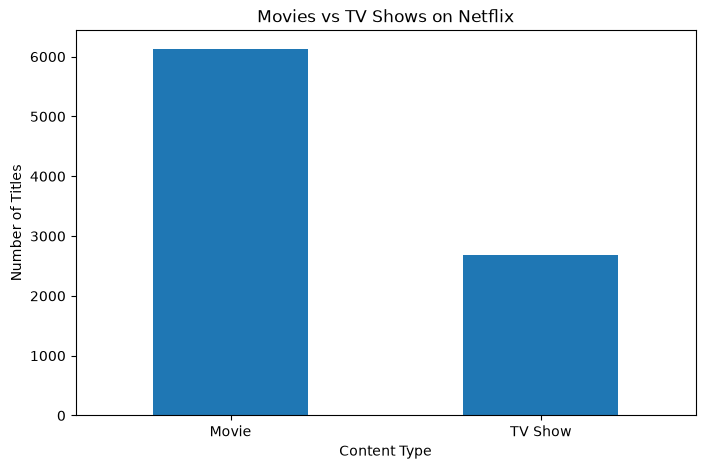

In [6]:
# Movies vs TV Shows visualization

plt.figure(figsize=(8, 5))

type_counts.plot(kind="bar")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)

plt.show()

In [7]:
# Number of Netflix titles released each year

release_year_counts = df["release_year"].value_counts().sort_index()

print("Titles by release year:")
print(release_year_counts.tail(20))

Titles by release year:
release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


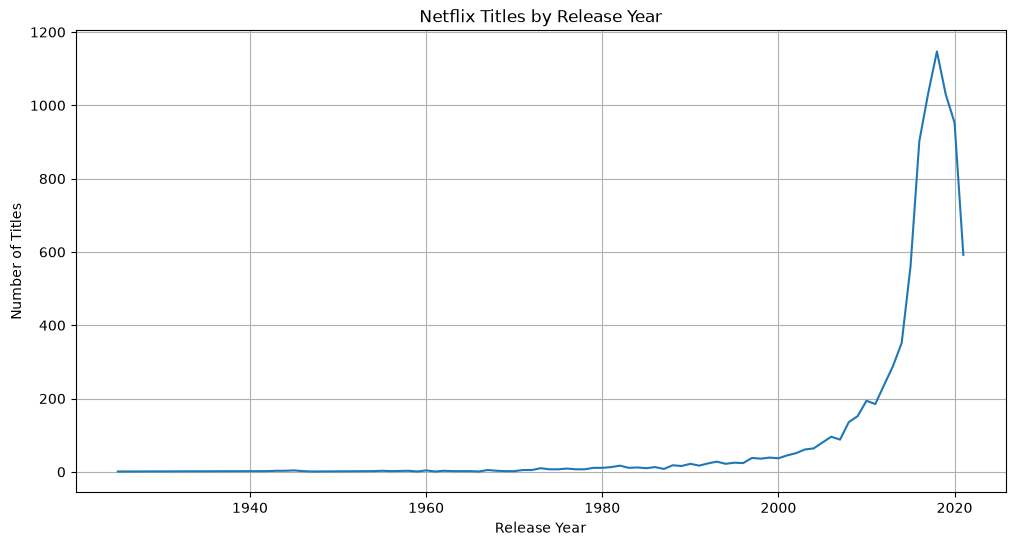

In [8]:
# Netflix content released by year

plt.figure(figsize=(12, 6))

release_year_counts.plot(kind="line")

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)

plt.show()

In [9]:
# Count titles by rating

rating_counts = df["rating"].value_counts()

print("Netflix titles by rating:")
print(rating_counts)


Netflix titles by rating:
rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


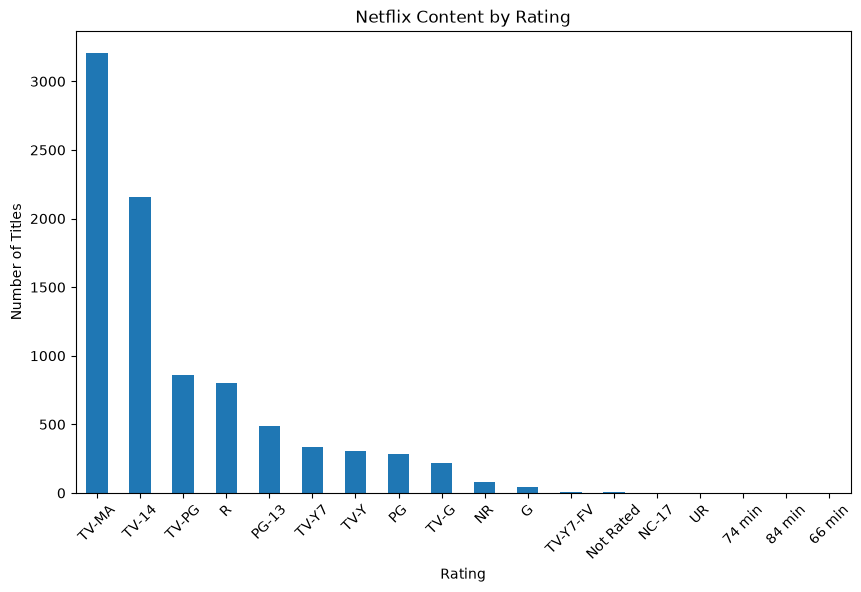

In [10]:
# Rating distribution

plt.figure(figsize=(10, 6))

rating_counts.plot(kind="bar")

plt.title("Netflix Content by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [13]:
# Load the corrected cleaned Netflix dataset
df = pd.read_csv("../02_Cleaned_Data/Cleaned_Netflix_Data.csv")

# Check the three corrected records
df[df["show_id"].isin(["s5542", "s5795", "s5814"])][
    ["show_id", "title", "rating", "duration"]
]

,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,Not Rated,74 min
5794,s5795,Louis C.K.: Hilarious,Not Rated,84 min
5813,s5814,Louis C.K.: Live at the Comedy Store,Not Rated,66 min


In [18]:
# Split multiple countries and count each country separately

country_data = df["country"].str.split(", ").explode()

# Remove missing/unknown country values
country_data = country_data[country_data != "Not Listed"]

country_counts = country_data.value_counts()

print("Top 20 countries by number of titles:")
print(country_counts.head(20))

Top 20 countries by number of titles:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Belgium             90
Name: count, dtype: int64


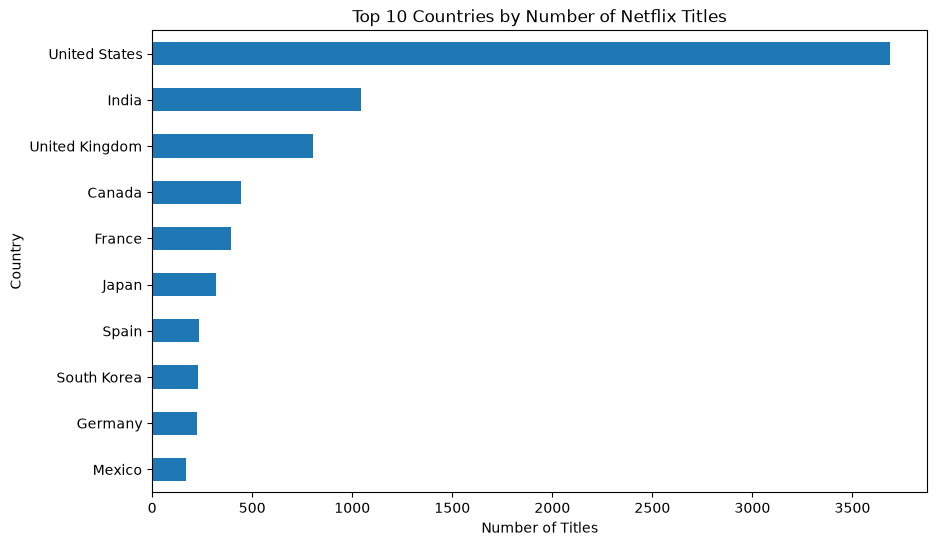

In [19]:
# Top 10 countries by number of Netflix titles

top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [16]:
# Split multiple countries and count each country separately

country_data = df["country"].str.split(", ").explode()

country_counts = country_data.value_counts()

print("Top 20 countries by number of titles:")
print(country_counts.head(20))

Top 20 countries by number of titles:
country
United States     3689
India             1046
Not Listed         831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Name: count, dtype: int64


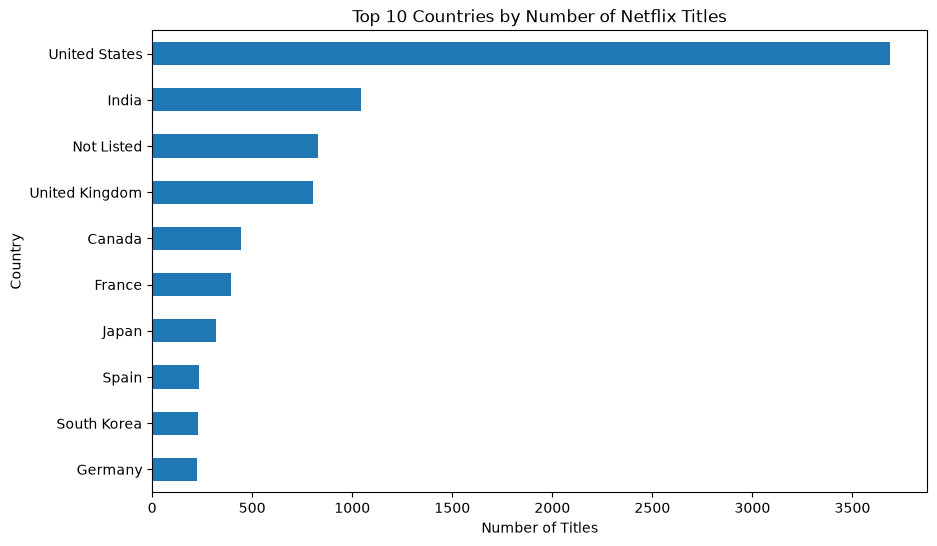

In [17]:
# Top 10 countries by number of Netflix titles

top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [3]:
# Split multiple genres and count each genre separately

genre_data = df["listed_in"].str.split(", ").explode()

genre_counts = genre_data.value_counts()

print("Top 20 genres:")
print(genre_counts.head(20))

Top 20 genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


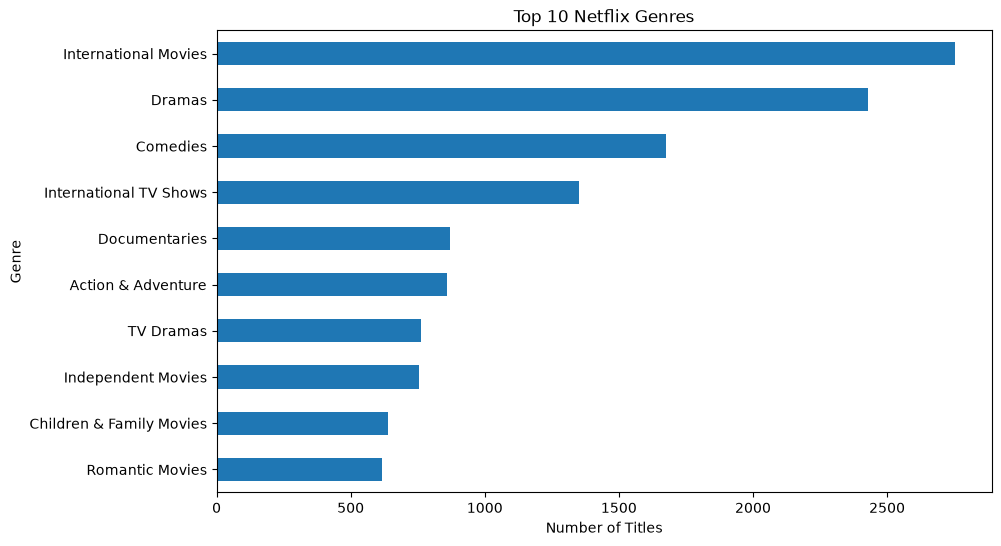

In [4]:
# Top 10 Netflix genres

top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

top_genres.sort_values().plot(kind="barh")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [5]:
# Separate Movie duration and TV Show seasons

movie_duration = df[df["type"] == "Movie"]["duration"]
tv_seasons = df[df["type"] == "TV Show"]["duration"]

print("Sample movie durations:")
print(movie_duration.head(10))

print("\nSample TV Show seasons:")
print(tv_seasons.head(10))

Sample movie durations:
0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
13     91 min
16     67 min
18     94 min
22    161 min
23     61 min
Name: duration, dtype: str

Sample TV Show seasons:
1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
8     9 Seasons
10     1 Season
11     1 Season
14     1 Season
15    4 Seasons
Name: duration, dtype: str


In [7]:
# Extract numeric duration values

df["duration_value"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Check the result
print(df[["type", "duration", "duration_value"]].head(15))

       type   duration  duration_value
0     Movie     90 min            90.0
1   TV Show  2 Seasons             2.0
2   TV Show   1 Season             1.0
3   TV Show   1 Season             1.0
4   TV Show  2 Seasons             2.0
5   TV Show   1 Season             1.0
6     Movie     91 min            91.0
7     Movie    125 min           125.0
8   TV Show  9 Seasons             9.0
9     Movie    104 min           104.0
10  TV Show   1 Season             1.0
11  TV Show   1 Season             1.0
12    Movie    127 min           127.0
13    Movie     91 min            91.0
14  TV Show   1 Season             1.0


In [8]:
# Movie duration analysis

movie_minutes = df[df["type"] == "Movie"]["duration_value"].dropna()

print("Movie Duration Analysis")
print("------------------------")
print("Average movie duration:", round(movie_minutes.mean(), 2), "minutes")
print("Shortest movie:", movie_minutes.min(), "minutes")
print("Longest movie:", movie_minutes.max(), "minutes")
print("Median movie duration:", movie_minutes.median(), "minutes")

Movie Duration Analysis
------------------------
Average movie duration: 99.58 minutes
Shortest movie: 3.0 minutes
Longest movie: 312.0 minutes
Median movie duration: 98.0 minutes


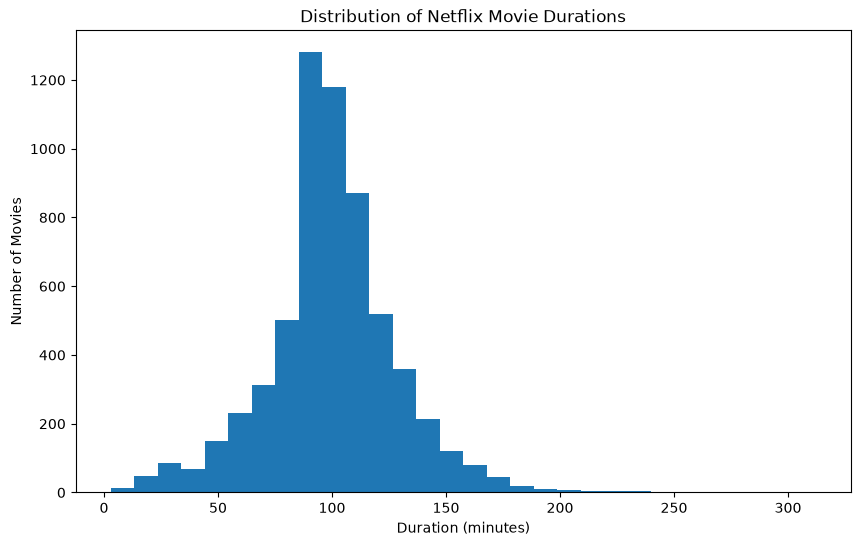

In [ ]:
# Distribution of movie durations

plt.figure(figsize=(10, 6))

plt.hist(movie_minutes, bins=30)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [10]:
# TV Show season analysis

tv_seasons = df[df["type"] == "TV Show"]["duration_value"].dropna()

print("TV Show Season Analysis")
print("-----------------------")
print("Average seasons:", round(tv_seasons.mean(), 2))
print("Minimum seasons:", int(tv_seasons.min()))
print("Maximum seasons:", int(tv_seasons.max()))
print("Median seasons:", tv_seasons.median())

TV Show Season Analysis
-----------------------
Average seasons: 1.76
Minimum seasons: 1
Maximum seasons: 17
Median seasons: 1.0


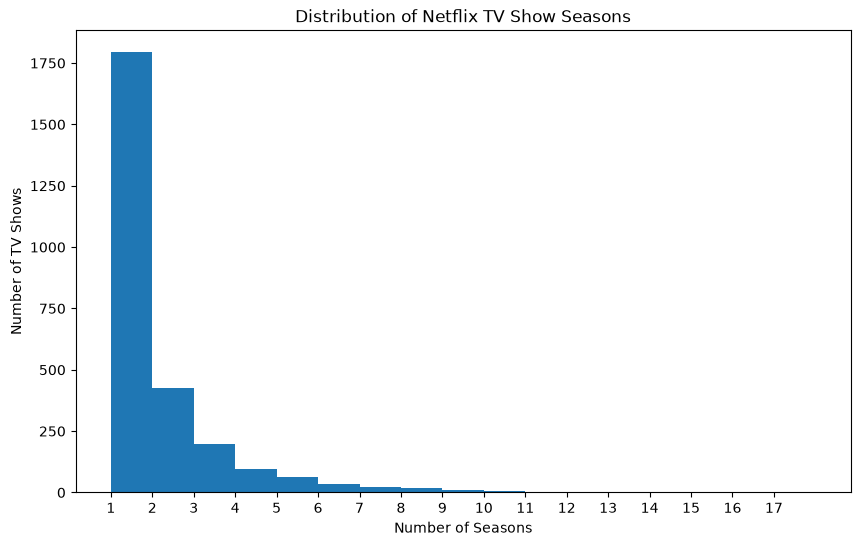

In [11]:
# Distribution of TV Show seasons

plt.figure(figsize=(10, 6))

plt.hist(tv_seasons, bins=range(1, int(tv_seasons.max()) + 2))

plt.title("Distribution of Netflix TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.xticks(range(1, int(tv_seasons.max()) + 1))

plt.show()

In [12]:
# Convert date_added to datetime

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

# Check the result
print(df[["title", "date_added"]].head(10))
print("\nMissing date_added values:", df["date_added"].isna().sum())

                              title date_added
0              Dick Johnson Is Dead 2021-09-25
1                     Blood & Water 2021-09-24
2                         Ganglands 2021-09-24
3             Jailbirds New Orleans 2021-09-24
4                      Kota Factory 2021-09-24
5                     Midnight Mass 2021-09-24
6  My Little Pony: A New Generation 2021-09-24
7                           Sankofa 2021-09-24
8     The Great British Baking Show 2021-09-24
9                      The Starling 2021-09-24

Missing date_added values: 10


In [13]:
# Netflix titles added by year

added_year_counts = (
    df["date_added"]
    .dropna()
    .dt.year
    .value_counts()
    .sort_index()
)

print("Netflix titles added by year:")
print(added_year_counts)

Netflix titles added by year:
date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


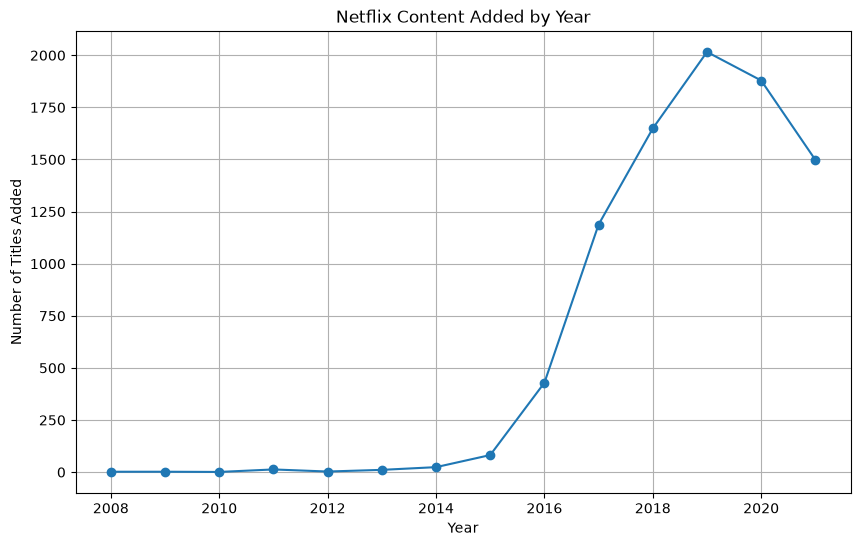

In [14]:
# Netflix content additions over time

plt.figure(figsize=(10, 6))

added_year_counts.plot(kind="line", marker="o")

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)

plt.show()

In [15]:
# Movies vs TV Shows added to Netflix by year

content_by_year = (
    df.dropna(subset=["date_added"])
    .groupby([df["date_added"].dt.year, "type"])
    .size()
    .unstack(fill_value=0)
)

print("Movies vs TV Shows added by year:")
print(content_by_year)

Movies vs TV Shows added by year:
type        Movie  TV Show
date_added                
2008.0          1        1
2009.0          2        0
2010.0          1        0
2011.0         13        0
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


<Figure size 1200x600 with 0 Axes>

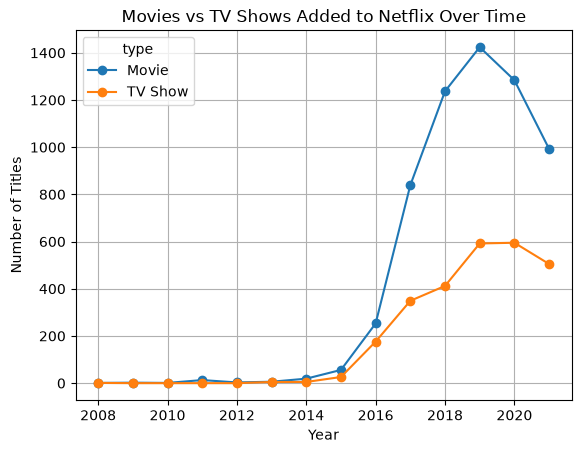

In [16]:
# Movies vs TV Shows added over time

plt.figure(figsize=(12, 6))

content_by_year.plot(kind="line", marker="o")

plt.title("Movies vs TV Shows Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

In [18]:
# Netflix Analysis - Final KPI Summary

# Basic KPIs
total_titles = len(df)
total_movies = (df["type"] == "Movie").sum()
total_tv_shows = (df["type"] == "TV Show").sum()

# Top Country
country_data = df["country"].str.split(", ").explode()
country_data = country_data[country_data != "Not Listed"]
country_counts = country_data.value_counts()

top_country = country_counts.index[0]
top_country_count = country_counts.iloc[0]

# Top Genre
genre_data = df["listed_in"].str.split(", ").explode()
genre_counts = genre_data.value_counts()

top_genre = genre_counts.index[0]
top_genre_count = genre_counts.iloc[0]

# Most Common Rating
rating_counts = df["rating"].value_counts()

top_rating = rating_counts.index[0]
top_rating_count = rating_counts.iloc[0]

# Movie duration
movie_minutes = df[df["type"] == "Movie"]["duration_value"].dropna()
average_movie_duration = movie_minutes.mean()

# TV Show seasons
tv_seasons = df[df["type"] == "TV Show"]["duration_value"].dropna()
average_tv_seasons = tv_seasons.mean()

# Display final summary
print("========== NETFLIX DATA ANALYSIS SUMMARY ==========")
print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)
print("Top Country:", top_country, "-", top_country_count, "titles")
print("Top Genre:", top_genre, "-", top_genre_count, "titles")
print("Most Common Rating:", top_rating, "-", top_rating_count, "titles")
print("Average Movie Duration:", round(average_movie_duration, 2), "minutes")
print("Average TV Show Seasons:", round(average_tv_seasons, 2))

========== NETFLIX DATA ANALYSIS SUMMARY ==========
Total Titles: 8807
Total Movies: 6131
Total TV Shows: 2676
Top Country: United States - 3689 titles
Top Genre: International Movies - 2752 titles
Most Common Rating: TV-MA - 3207 titles
Average Movie Duration: 99.58 minutes
Average TV Show Seasons: 1.76
